In [42]:
# load data
import pandas as pd

data = pd.read_csv("../../data/raw/WESAD/S2/S2_E4_Data/BVP.csv", header=None, names=["BVP"])
 
bvp = data['BVP'].iloc[2:].astype(float).values      #iloc= necessary, it starts from index 2

In [43]:
# filter
from scipy.signal import butter, filtfilt
import numpy as np

# Sampling frequency
fs = 64

# Bandpass range
lowcut = 0.7
highcut = 5

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

bvp_filtered = filtfilt(b, a, bvp)


In [44]:
# normalise
import numpy as np
import pandas as pd


def normalize_signal(signal):
    signal = np.array(signal)
    return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

bvp_norm= normalize_signal (bvp_filtered)                           ######

In [45]:
# window pipeline
def create_overlapping_windows(signal, fs=64, window_size_sec=5, overlap=0.5):
    signal = np.array(signal)

    window_size = int(window_size_sec * fs)
    step_size = int(window_size * (1 - overlap))

    windows = []

    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])

    return np.array(windows)
eda_windows = create_overlapping_windows(bvp_norm, fs=64)           ########

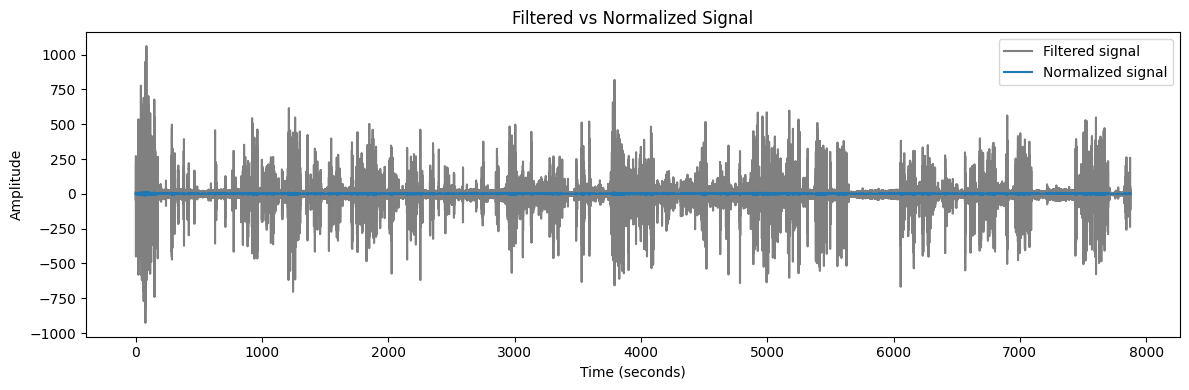

Created 2623 windows, each 6 sec long, overlapping by 3 sec


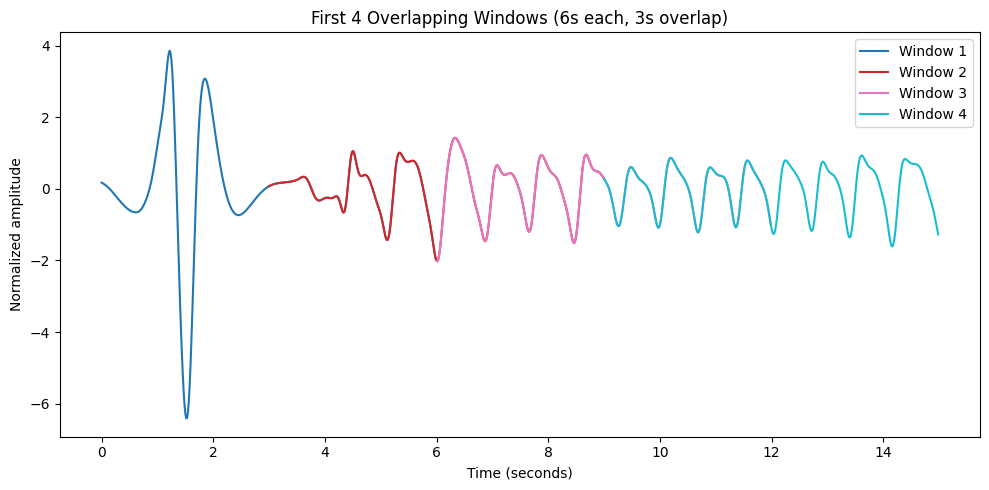

In [47]:
"""
================================================================
HOW TO USE THIS CODE (read this first)
================================================================

You already have a FILTERED signal (a list/array of numbers).
This code will:
   STEP 1: Normalize it
   STEP 2: Plot FILTERED vs NORMALIZED signal (to compare them)
   STEP 3: Cut it into overlapping windows (5-10 sec each)
   STEP 4: Plot the first few windows on a SHORT time axis,
           so you can clearly see how they overlap

WHAT YOU NEED TO CHANGE (marked with ">>>"):
   1. Put your filtered signal into `my_filtered_signal`
   2. Set `fs` to your signal's sampling frequency

Then just run the file.
================================================================
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------
# >>> STEP 1: PUT YOUR DATA HERE <<<
# ----------------------------------------------------------------

# Replace this with your actual FILTERED signal (a list or numpy array)
my_filtered_signal =  bvp_filtered
# (the line above is just example/demo data, 30 seconds at 250 Hz — delete it and use your own)

# Replace this with your real sampling frequency (Hz)
fs = 64   # <-- e.g. 250 for ECG, 1000 for EMG, 4 for some PPG sensors


# ----------------------------------------------------------------
# Window settings — keep window length between 5 and 10 seconds
# ----------------------------------------------------------------
window_length_sec = 6     # length of each window (5-10 sec)
overlap_sec = 3            # how much each window overlaps the previous one

how_many_windows_to_plot = 4   # how many windows to show overlapping in the plot


# ==================================================================
# Nothing below this line needs to be changed
# ==================================================================

filtered_signal = np.array(my_filtered_signal, dtype=float)

# ---- STEP 1: Normalize the filtered signal ----
mean_value = filtered_signal.mean()
std_value = filtered_signal.std()
normalized_signal = (filtered_signal - mean_value) / std_value

time_axis = np.arange(len(filtered_signal)) / fs   # time in seconds for full signal


# ---- STEP 2: Plot FILTERED vs NORMALIZED (full signal) ----
plt.figure(figsize=(12, 4))
plt.plot(time_axis, filtered_signal, label="Filtered signal", color="gray")
plt.plot(time_axis, normalized_signal, label="Normalized signal", color="tab:blue")
plt.title("Filtered vs Normalized Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


# ---- STEP 3: Cut the normalized signal into overlapping windows ----
window_length_samples = int(window_length_sec * fs)
step_samples = int((window_length_sec - overlap_sec) * fs)

windows = []          # stores the actual window data
window_start_times = []  # stores when each window starts (in seconds)

start = 0
while start + window_length_samples <= len(normalized_signal):
    windows.append(normalized_signal[start : start + window_length_samples])
    window_start_times.append(start / fs)
    start += step_samples

print(f"Created {len(windows)} windows, each {window_length_sec} sec long, "
      f"overlapping by {overlap_sec} sec")


# ---- STEP 4: Plot first few windows overlapping, on a SHORT time axis ----
plt.figure(figsize=(10, 5))

n_to_plot = min(how_many_windows_to_plot, len(windows))
colors = plt.cm.tab10(np.linspace(0, 1, n_to_plot))

for i in range(n_to_plot):
    window_data = windows[i]
    window_time = np.arange(len(window_data)) / fs + window_start_times[i]
    plt.plot(window_time, window_data, color=colors[i], label=f"Window {i+1}")

plt.title(f"First {n_to_plot} Overlapping Windows ({window_length_sec}s each, "
          f"{overlap_sec}s overlap)")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.tight_layout()
plt.show()
